2.354564459136067
0.2772588722239781


(199000.0, 201000.0)

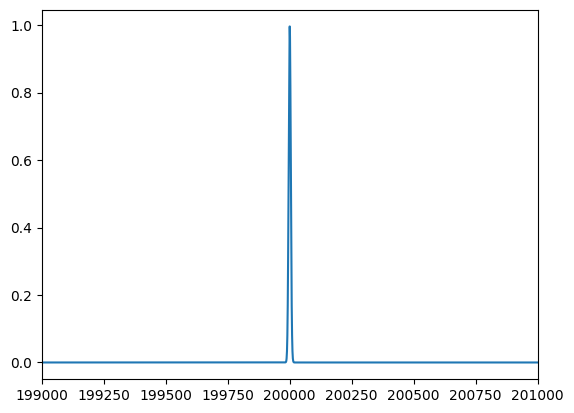

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import curve_fit
from scipy.fft import fft, ifft, fftfreq, fftshift
import math
import matplotlib.ticker as ticker
from scipy.stats import binned_statistic
import random

def E_of_t_laser(fwhm, t, t_0, w_0):
    return np.exp((-2*math.log(2)*((t - t_0)**2))/(fwhm**2))*np.exp(-1j*w_0*t)

fwhm = 10 #fs
c = 299792458
w_0 = 2*np.pi*c*1e-15/800e-9
print(w_0)
t_0 = 200000
Npts = 2**19
ts = np.linspace(0, 400000, Npts)
dt = ts[1] - ts[0]
#ts = np.linspace(150, 250, 500)
Es = E_of_t_laser(fwhm, ts, t_0, w_0)

'''
w = 2pi*f
2 ln 2 /pi (3.2 * 10^12)

fwhm t * fwhm f = 2 ln 2/pi (gaussian pulse)
fwhm w = 2*pi*fwhm f
fwhm t *fwhm w/2pi = 2ln2/pi
fwhm t * fwhm w = 4ln 2
fwhm w = 4 ln 2 / fwhm t
'''
fwhm_w = 4*np.log(2)/fwhm
print(fwhm_w)
plt.plot(ts, np.abs(Es)**2)
plt.xlim(199000,201000)


0.0007425790513595704


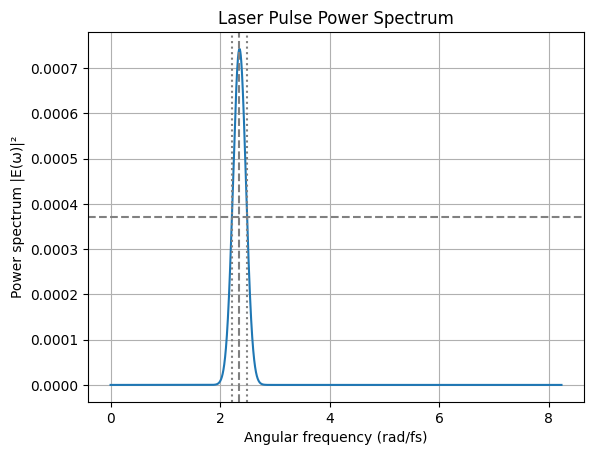

In [5]:
'''
Mathematica's Fourier transform uses a positively-signed (clockwise-spinned) exponent, whereas
Python uses a negatively-signed exponent. This has the effect of conjugating the input and output,
so we use np.conj to get results matching Mathematica

norm = 'ortho' scales both forward and backward transforms by 1/sqrt(N) (N number of points)
'''
Ews = np.conj(fft(np.conj(Es), norm = 'ortho'))

#matching Mathematica code way to get ws
ws = 2 * np.pi * np.arange(Npts) / (Npts * dt)

Ews_power = np.abs(Ews)**2
maxU = np.max(Ews_power)
print(maxU)

plt.plot(ws, Ews_power)
plt.axhline(maxU / 2, color='gray', linestyle='--')  # horizontal at half max
plt.axvline(w_0, color='gray', linestyle='--')        # center frequency
plt.axvline(2.2159, color='gray', linestyle=':')     # example verticals
plt.axvline(2.4932, color='gray', linestyle=':')

plt.xlabel("Angular frequency (rad/fs)")
plt.ylabel("Power spectrum |E(ω)|²")
plt.title("Laser Pulse Power Spectrum")
plt.grid()
plt.show();

mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628


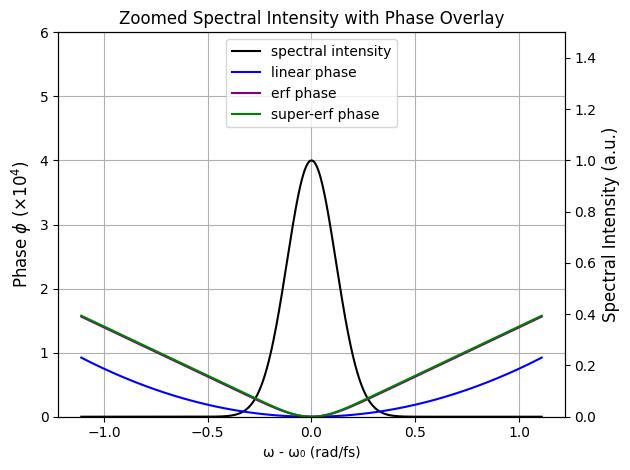

In [41]:
from scipy.special import erf
import random

def chirper(Ews, phi):
    return Ews*np.exp(1j*phi)

def lin_chirp(A, w, w_0):
    return 0.5*A*((w - w_0)**2)

#erf chirp equation from the paper -> noah says the square was a typo; so this is wrong
def erf_chirp(B, w, w_0, sigma):

    x = (w - w_0)*sigma/math.sqrt(4*math.log(2))

    return B*(((np.exp(-x**2) - 1)/math.sqrt(np.pi) + x*erf(x))**2)

#erf chirp from the mathematica code
def erf_2(B, w, w_0, sigma):
    x = (w - w_0)*2*sigma/math.sqrt(2*math.log(256))
    return B*((np.exp(-x**2) - 1)/math.sqrt(np.pi) + x*erf(x))

#super erf chirp from mathematica code 
def superf_chirp(C, w, w_0, sigma_s):
    x = (w - w_0)*2*sigma_s / math.sqrt(2*math.log(256))
    return C*((np.exp(-x**2) - 1)/math.sqrt(np.pi) + x*erf(x))


A = 180337*2
A = 15000
B = 2562#8300
C = 2287#7450

sigma_s = 1.12*fwhm #she had this hardcoded in to her super erf function

pos_lin = lin_chirp(A, ws, w_0)
neg_lin = -pos_lin

pos_erf = erf_2(B, ws, w_0, fwhm)
neg_erf = erf_2(-B, ws, w_0, fwhm)

pos_superf = superf_chirp(C, ws, w_0, sigma_s)
neg_superf = superf_chirp(-C, ws, w_0, sigma_s)

SLM_mask = []

num_pixels = 4160


##########################################
# What I'm trying to do:
# 1. Find the indices of ws that correspond to the values closest to +/- 1.5*fwhm while still being divisible
#    by the number of pixels (in this case I'm adding remainder so values will go a bit above 3*fwhm)
#    This is stored in mod_indices
# 2. create freq_mod and phi_mod arrays that are the respective slices of ws and pos_lin within those indices
# 3. Create bin_edges array that holds the value of freq_mod at the edges of each bin (num_pixels amount of bins)
# 4. create edge_indices array that holds the index of each bin edge
# 5. Create phi_binned using scipy.binned_statistic which will return an array the size of num_bins, with each value
# 6. in phi_binned being the average value of the corresponding bin
# 7. Create phi_test, a zeroes array the size of ws
# 8. now set phi_test[edge_indices[i]:edge_indices[i+1]] = phi_binned[i], meaning within the range we defined
#    our mask over, set the value of indices corresponding to each bin to the value of that bin
#

def realistic_SLM(ws, w_0, fwhm, phase, num_pixels = 800, bit_depth = 2**8 - 1, uncertainty_bin = 1):
    '''
    w = 2pi*f

    fwhm t * fwhm f = 2 ln 2/pi (gaussian pulse)
    fwhm w = 2*pi*fwhm f
    fwhm t *fwhm w/2pi = 2ln2/pi
    fwhm t * fwhm w = 4ln 2
    fwhm w = 4 ln 2 / fwhm t
    '''
    fwhm_w = 4*np.log(2)/fwhm
    SLM_mask = np.zeros_like(ws)

    # Step 1: Get index of center frequency
    i_center = np.argmin(np.abs(ws - w_0))

    # Step 2: Desired number of modulation points (must be divisible by num_pixels)
    df = ws[2] - ws[1]
    mod_bw = 3 * fwhm_w  # Total width = ±1.5*fwhm
    N_target = int(np.round(mod_bw / df))  # number of points in ±3*fwhm

    # Round up to nearest multiple of num_pixels
    remainder = N_target % num_pixels
    if remainder != 0:
        N_target += (num_pixels - remainder)

    # Step 3: Make symmetric indices around w0
    half_N = N_target // 2
    i_start = max(i_center - half_N, 0)
    i_end = i_start + N_target

    # Clip if we exceed array bounds
    if i_end > len(ws):
        i_end = len(ws)
        i_start = i_end - N_target

    mod_indices = np.arange(i_start, i_end)

    # Confirm divisibility
    assert len(mod_indices) % num_pixels == 0
    print(f"mod_indices length: {len(mod_indices)}, divisible by {num_pixels}")

    freq_mod = ws[mod_indices]
    phi_mod = phase[mod_indices]  # UNWRAPPED phase!
    SLM_mask[mod_indices] = 1

    # Step 2: Bin to n pixels (averaging unwrapped phase)
    bin_edges = np.linspace(freq_mod[0], freq_mod[-1], num_pixels + 1)
    edge_indices = np.linspace(mod_indices[0], mod_indices[-1]+ 1, num_pixels + 1, dtype=int)
    phi_binned, _, _ = binned_statistic(freq_mod, phi_mod, statistic='mean', bins=bin_edges)

    phi_test = np.zeros_like(ws)

    print("delta w total: ", ws[mod_indices[-1]] - ws[mod_indices[0]])
    print("delta w: ", ws[2] - ws[1])
    print("spacing bw frequencies in different bins: ", bin_edges[1] - bin_edges[0])

    #will it perform better if phase is just smooth outside of the SLM range instead of 0?
    #is that realistic?
    #phi_test = np.copy(phase)

    for i in range(0, len(edge_indices) - 1):
        
        phi_test[edge_indices[i]:edge_indices[i+1]] = phi_binned[i]

    # Step 3: Wrap the binned phase
    phi_test = np.mod(phi_test, 2*np.pi)


    ##trying to add in the random phase part
    #uncertainty_rad = uncertainty_deg*np.pi/180
    #for i in range(0, len(edge_indices) - 1):
        #phi_test[edge_indices[i]:edge_indices[i+1]] = random.gauss(phi_test[edge_indices[i]], uncertainty_rad)

    phi_test = np.round(phi_test/(2*np.pi)*bit_depth)
    phi_test = phi_test/bit_depth * np.pi * 2

    uncertain_phi = np.copy(phi_test)
    '''
    if uncertainty_bin != 0:
        for i in range(uncertainty_bin, len(edge_indices) - 1 - uncertainty_bin):
            uncertain_phi[edge_indices[i]:edge_indices[i+1]] = random.choice(phi_test[edge_indices[i - uncertainty_bin:i + uncertainty_bin + 1]])
    '''
    #trying to add in the random phase part
    uncertainty_rad = uncertainty_bin*np.pi/180
    for i in range(0, len(edge_indices) - 1):
        uncertain_phi[edge_indices[i]:edge_indices[i+1]] = random.gauss(phi_test[edge_indices[i]], uncertainty_rad)

    return uncertain_phi, SLM_mask, ws[mod_indices[-1]] - ws[mod_indices[0]], bin_edges[1] - bin_edges[0]

pos_unbinned = np.copy(pos_lin)
pos_unbinned %= 2*np.pi
pos_realistic = np.copy(pos_unbinned)


phi_test, SLM_mask, delta_w, del_w = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 3)

bit_depth = 2**8 - 1

# bit crushing - pixels can oto simulate this, divide the phase shift by 2pi multiply by the 
# bit depth (256 or whatever) then round to nearest whole number
# divide by the bitdepth then multiply by 2pi
pos_realistic = np.round(pos_realistic/(2*np.pi)*bit_depth)
pos_realistic = pos_realistic/bit_depth * np.pi * 2

ws_centered = ws - w_0
power_norm = Ews_power / maxU 

# Zoom in: find center index and plot surrounding region
i_center = np.argmin(np.abs(ws - w_0))
window = 4 * 17651
i_start = max(i_center - window, 0)
i_end = min(i_center + window, len(ws))

# Plot
fig, ax1 = plt.subplots()

# Left y-axis: Phase (shifted by - w_0 to align with 0 on x axis)
ax1.plot(ws_centered[i_start:i_end], power_norm[i_start:i_end] * 4, color='black', label='spectral intensity') # multiplied by 4 because maggie does it; ask why
ax1.plot(ws_centered[i_start:i_end], pos_lin[i_start:i_end] / 1e4, label='linear phase', color='blue')
ax1.plot(ws_centered[i_start:i_end], pos_erf[i_start:i_end] / 1e4, label='erf phase', color='purple')
ax1.plot(ws_centered[i_start:i_end], pos_superf[i_start:i_end] / 1e4, label='super-erf phase', color='green')
ax1.set_ylim(0, 6)
ax1.set_xlabel("ω - ω₀ (rad/fs)")
ax1.set_ylabel(r"Phase $\phi$ ($\times10^4$)", fontsize=12)
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')
ax1.grid(True)

# --- Create secondary y-axis sharing the x-axis
ax2 = ax1.twinx()

# Map ax2 limits: 0 to 1.5 a.u. corresponds to 0 to 6 on other plot
ax2.set_ylim(0, 1.5)
ax2.set_ylabel("Spectral Intensity (a.u.)", fontsize=12)

# --- Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='upper center')

plt.title("Zoomed Spectral Intensity with Phase Overlay")
plt.tight_layout()
plt.show()

In [30]:
'''
Finding max possible chirping!

applying a spectral phase phi but discretely, where the difference between frequencies at each bin edge (pixel)
is del_w.
To avoid aliasing, phase change between adjacent pixels must be less than pi -> |phi(w + del_w) - phi(w)| < pi

For linear, phi = (A/2)(w - w_0)**2
Using that at the extreme case (aka ends of w spectrum), w - w_0 = delta_w/2, we get

A < 2pi/(del_w*delta_w + del_w^2)

For erf, phi = B * psi(x), where psi(x) = (e^-x^2 - 1)/sqrt(pi) + xerfx
x =  (constant terms) * (w - w0)
del_x = (constant terms) *(del_w -> frequency spacing bw pixels)

so for erf |phi(w + del_w) - phi(w)| < pi = |B||psi(x + del_x) - psi(x)|

-> |B| < pi/|psi(x + del_x) - psi(x)|
and again, replacing w - w0 with  delta_w/2 for the worst case at the edges
'''

def get_max_chirp_lin(delta_w, del_w):
    return 2*np.pi/(del_w*delta_w + del_w**2)

def get_max_chirp_erf(delta_w, del_w, sigma):
    x_del = (delta_w/2 + del_w)*2*sigma/math.sqrt(2*math.log(256))
    x = (delta_w/2)*2*sigma/math.sqrt(2*math.log(256))

    def psi(a):
        return (np.exp(-(a**2)) - 1)/math.sqrt(np.pi) + a*erf(a)

    return np.pi/np.abs(psi(x_del) - psi(x))

print("Linear: ", get_max_chirp_lin(delta_w, del_w))
print("Erf: ", get_max_chirp_erf(delta_w, del_w, fwhm))

Linear:  36213.74272853364
Erf:  2562.5487655284846


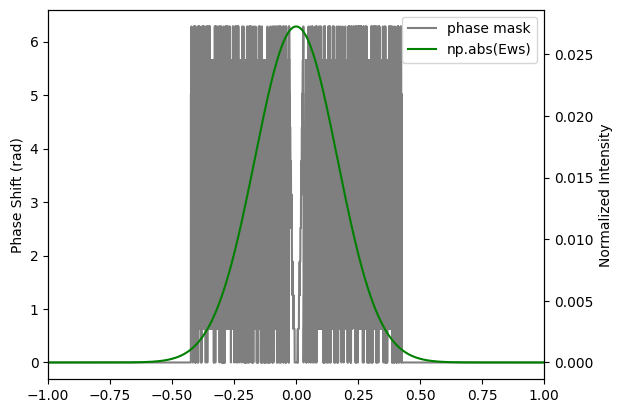

In [31]:
fig, ax1 = plt.subplots()
l1 = ax1.plot(ws_centered, phi_test, 'k', alpha=0.5)
#l1 = ax1.plot(ws_centered, pos_unbinned, 'k', alpha=0.5)
ax1.set_ylabel("Phase Shift (rad)")
ax1.set_xlim(-1, 1)
ax2 = ax1.twinx()
#l2 = ax2.plot(ws_centered, power_norm, '#ff7f0e')
l2 = ax2.plot(ws_centered, np.abs(Ews), color = 'green')


ax2.set_ylabel("Normalized Intensity")

ax2.legend([l1[0], l2[0]], ['phase mask', "np.abs(Ews)"])

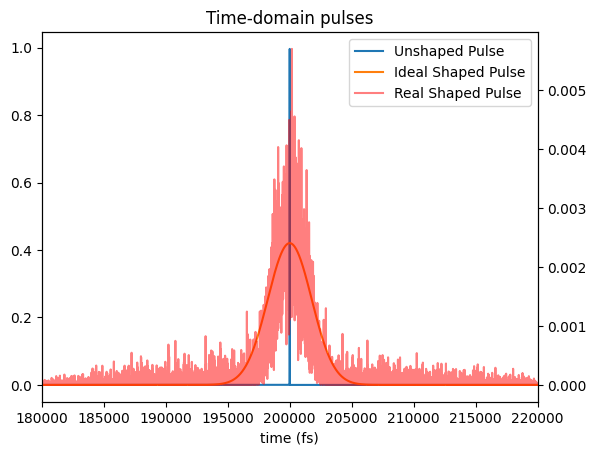

In [33]:
E_w_shaped_ideal = chirper(Ews, pos_unbinned)
#E_w_shaped_realistic = chirper(Ews, pos_realistic)*SLM_mask
E_w_shaped_binned = chirper(Ews, phi_test)*SLM_mask
#E_w_shaped_old = chirper(Ews, pos_lin)


E_t_shaped_ideal = np.conj(ifft(np.conj(E_w_shaped_ideal), norm = 'ortho'))
#E_t_shaped_realistic = np.conj(ifft(np.conj(E_w_shaped_realistic), norm = 'ortho'))
E_t_shaped_binned = np.conj(ifft(np.conj(E_w_shaped_binned), norm = 'ortho'))
#E_t_shaped_old = np.conj(ifft(np.conj(E_w_shaped_old), norm = 'ortho'))

fig, ax1 = plt.subplots()


ax1.set_title("Time-domain pulses")


l0 = ax1.plot(ts, np.abs(Es)**2)

ax2 = ax1.twinx()

l1 = ax2.plot(ts, np.abs(E_t_shaped_ideal)**2, '#ff7f0e')
#l2 = ax2.plot(ts, np.abs(E_t_shaped_realistic)**2, '#2ca02c', alpha = 0.7)
l3 = ax2.plot(ts, np.abs(E_t_shaped_binned)**2, color="red", alpha = 0.5)

# plt.ylim(-0.05e6, 0.5e6)
ax1.set_xlim(180000, 220000)
ax1.set_xlabel("time (fs)")

ax1.legend([l0[0], l1[0], l3[0]], ["Unshaped Pulse", "Ideal Shaped Pulse", "Real Shaped Pulse"])

mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628
mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628
mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628
mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628
mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spacing bw frequencies in different bins:  0.00020419935705051628
mod_indices length: 54080, divisible by 4160
delta w total:  0.8494693253301657
delta w:  1.57079333073867e-05
spac

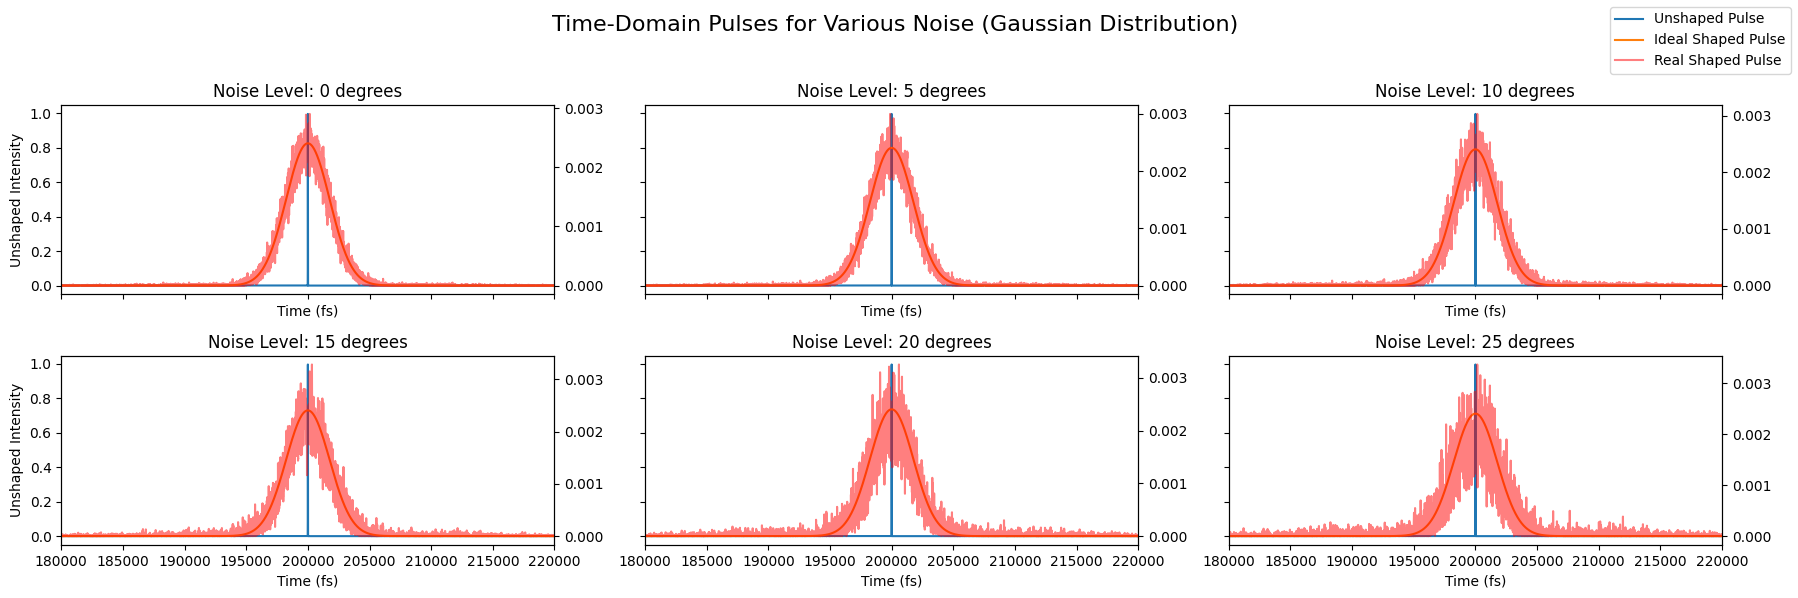

In [43]:
phi_test_0, SLM_mask_0, delta_w_0, del_w_0 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 0)
phi_test_1, SLM_mask_1, delta_w_1, del_w_1 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 5)
phi_test_2, SLM_mask_2, delta_w_2, del_w_2 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 10)
phi_test_3, SLM_mask_3, delta_w_3, del_w_3 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 15)
phi_test_5, SLM_mask_5, delta_w_5, del_w_5 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 20)
phi_test_10, SLM_mask_10, delta_w_10, del_w_10 = realistic_SLM(ws, w_0, fwhm, pos_lin, num_pixels, 10, 25)

phi_list = [phi_test_0, phi_test_1, phi_test_2, phi_test_3, phi_test_5, phi_test_10]
SLM_mask_list = [SLM_mask_0, SLM_mask_1, SLM_mask_2, SLM_mask_3, SLM_mask_5, SLM_mask_10]
noises = [0, 5, 10, 15, 20, 25]

E_w_real = []

for i in range(6):
    E_w_real.append(chirper(Ews, phi_list[i])*SLM_mask_list[i])

E_t_real = []

for i in range(6):
    E_t_real.append(np.conj(ifft(np.conj(E_w_real[i]), norm = 'ortho')))

fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to simplify indexing

for i in range(6):
    ax1 = axes[i]
    ax2 = ax1.twinx()  # create secondary y-axis for this subplot


    l0 = ax1.plot(ts, np.abs(Es)**2, label="Unshaped Pulse")
    l1 = ax2.plot(ts, np.abs(E_t_shaped_ideal)**2, '#ff7f0e', label="Ideal Shaped Pulse")
    l3 = ax2.plot(ts, np.abs(E_t_real[i])**2, color="red", alpha=0.5, label="Real Shaped Pulse")

    ax1.set_xlim(180000, 220000)
    ax1.set_xlabel("Time (fs)")

    if i % 3 == 0:
        ax1.set_ylabel("Unshaped Intensity")
    if i >= 3:
        ax1.set_xlabel("Time (fs)")
    if i == 1:
        ax1.set_title("Time-Domain Pulses")

    # Only add legend to one subplot (or do fig.legend outside if you prefer)
    if i == 0:
       fig.legend(loc="upper right")
       

    ax1.set_title(f"Noise Level: {noises[i]} degrees")

# Global title and layout
plt.suptitle("Time-Domain Pulses for Various Noise (Gaussian Distribution)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("time_domain_grid.png", bbox_inches="tight")
plt.show()


524288
524288
524288


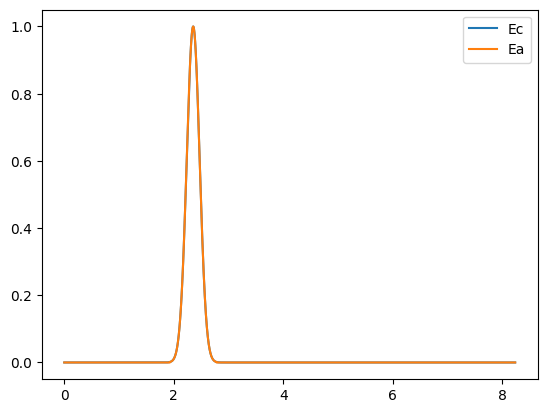

In [14]:

Ec_lin = chirper(Ews, phi_test)*SLM_mask
Ea_lin = chirper(Ews, -phi_test)*SLM_mask

Ec_lin = chirper(Ews, pos_lin)



Ec_erf = chirper(Ews, pos_erf)
Ea_erf = chirper(Ews, neg_erf)

Ec_superf = chirper(Ews, pos_superf)
Ea_superf = chirper(Ews, neg_superf)

Ec_lin_t = np.conj(ifft(np.conj(Ec_lin), norm = 'ortho'))
Ec_erf_t = np.conj(ifft(np.conj(Ec_erf), norm = 'ortho'))
Ec_superf_t = np.conj(ifft(np.conj(Ec_superf), norm = 'ortho'))

print(len(ts))
print(len(ws))
print(len(Ews))

#plt.plot(ts, np.abs(Es)**2)
#this is much smaller height wise than expected, but about as wide?
#plt.plot(ts, np.abs(Ec_lin_t)**2)
#plt.plot(ts, np.abs(Ec_erf_t)**2)
#plt.plot(ts, np.abs(Ec_superf_t)**2)
plt.plot(ws, np.abs(Ec_lin)**2/np.max(np.abs(Ec_lin)**2), label='Ec')
plt.plot(ws, np.abs(Ea_lin)**2/np.max(np.abs(Ea_lin)**2), label='Ea')
#plt.xlim(199900,200100)
plt.legend()

Linear FWHM: 10040.380519739925
Erf FWHM: 30770.169773425616
Super Erf FWHM: 30770.169773425616


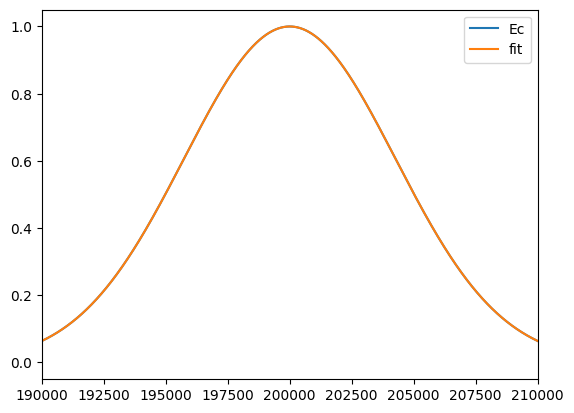

In [15]:
from scipy.optimize import least_squares
Ec_t = np.conj(ifft(np.conj(Ec_lin), norm='ortho'))

Ec_abs_norm = np.abs(Ec_t/np.max(Ec_t))**2

def gaussian(t, t_0, a1, fwhm):
    return a1*np.exp(-4*np.log(2)*((t - t_0)**2)/fwhm**2)

def residuals(params, t, y):
    T0, a1, sigma = params
    model = (a1 * np.exp(-4 * np.log(2) * (t - T0)**2 / sigma**2))
    return model - y

init_guess = [200000, 1, 100]
params = least_squares(residuals, init_guess, args=(ts, Ec_abs_norm), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x
curve = gaussian(ts, *params)

def compute_fwhm(t, E_t):
    intensity = np.abs(E_t)**2
    intensity /= np.max(intensity)  # normalize

    half_max = 0.5
    indices = np.where(intensity > half_max)[0]

    if len(indices) < 2:
        return None  # can't compute FWHM

    t_fwhm = t[indices[-1]] - t[indices[0]]
    return t_fwhm, t[indices[0]], t[indices[-1]]


print(f"Linear FWHM: {params[2]}")
print(f"Erf FWHM: {compute_fwhm(ts, Ec_erf_t)[0]}")
print(f"Super Erf FWHM: {compute_fwhm(ts, Ec_superf_t)[0]}")


plt.plot(ts, Ec_abs_norm, label='Ec')
plt.plot(ts, curve, label = "fit")
plt.xlim(190000,210000)
plt.legend()


okaie trying with linear nowww

In [16]:

def Ereffer(Ec, Ea, w, tau):
    return (Ec + Ea)*np.exp(1j*w*tau)

def Esampler(Ec, Ea, w, w_0, epsilon):
    return (Ec - Ea)*np.exp(1j*epsilon*((w - w_0)**2))

#need to calculate these in frequency domain, then ifft into time domain

taus = np.arange(-25, 25 + 0.5, 0.5)
#taus = np.arange(0, 200 + 0.5, 0.5)
'''
Esamp_lin_w = Esampler(Ec_lin, Ea_lin, ws, w_0, 0)
Esamp_lin_t = np.conj(ifft(np.conj(Esamp_lin_w), norm = 'ortho'))

SFG_data = []

for tau in taus:
    Eref_lin_w = Ereffer(Ec_lin, Ea_lin, ws, tau)
    Esfg_lin_t = np.conj(ifft(np.conj(Eref_lin_w), norm = 'ortho'))*Esamp_lin_t
    Esfg_lin_w = np.conj(fft(np.conj(Esfg_lin_t), norm = 'ortho'))
    Isfg_lin_w = np.abs(Esfg_lin_w)**2
    SFG_data.append(Isfg_lin_w)

SFG_data = np.array(SFG_data)
'''

def CPI(Ec, Ea, ws, w_0, taus, epsilon):
    Esamp_w = Esampler(Ec, Ea, ws, w_0, epsilon)
    Esamp_t = np.conj(ifft(np.conj(Esamp_w), norm = 'ortho'))

    SFG_data = []

    for tau in taus:
        Eref_w = Ereffer(Ec, Ea, ws, tau)
        Esfg_t = np.conj(ifft(np.conj(Eref_w), norm = 'ortho'))*Esamp_t
        Esfg_w = np.conj(fft(np.conj(Esfg_t), norm = 'ortho'))
        Isfg_w = np.abs(Esfg_w)**2
        SFG_data.append(Isfg_w)

    SFG_data = np.array(SFG_data)
    return SFG_data

lin_cpi = CPI(Ec_lin, Ea_lin, ws, w_0, taus,  0.0223238*0)
erf_cpi = CPI(Ec_erf, Ea_erf, ws, w_0, taus,  0.0223238*0)
superf_cpi =CPI(Ec_superf, Ea_superf, ws, w_0, taus,  0.0223238*0)


for some reasons maggies plot is one pixel wider on the y-axis than mine. is this because i removed the first points where w = 0?

Start index: 299419, End index: 300169
Wavelength range: 400.50 - 399.50 nm


C:\Users\Berjoska\AppData\Local\Temp\ipykernel_22932\2333764551.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


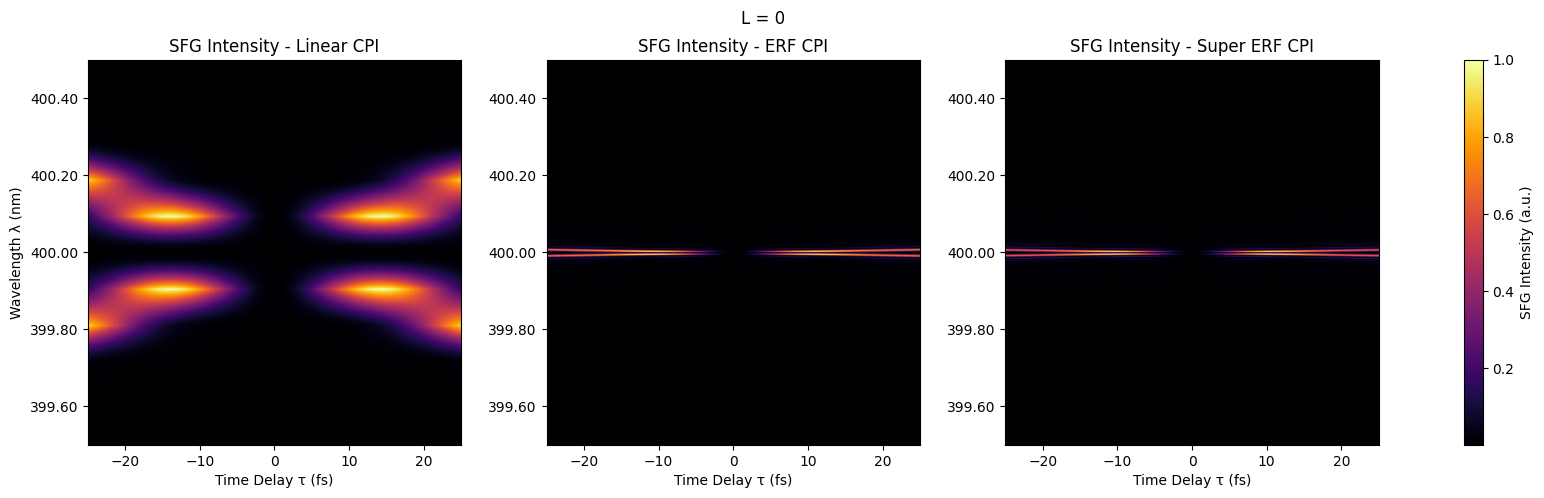

In [60]:
from matplotlib import gridspec
#skipping the first bin of everything now
ws[0] = 1e-6

# --- Generate wavelength axis ---
wavelengths = 2 * np.pi * c * 1e9 / (ws * 1e15)

# --- Correct indices (Python is 0-based) ---
start = 299753
end = 299833

# Find indices where wavelength is within the desired range
matching_indices = np.where((wavelengths >= 399.5) & (wavelengths <= 400.5))[0]

# Ensure there are valid matches
if len(matching_indices) > 0:
    start = matching_indices[0]
    end = matching_indices[-1] + 1  # +1 to make it sliceable: [start:end]
    print(f"Start index: {start}, End index: {end}")
    print(f"Wavelength range: {wavelengths[start]:.2f} - {wavelengths[end-1]:.2f} nm")
else:
    print("No wavelengths in the specified range.")

# --- Normalize datasets ---
lin_cpi_norm = lin_cpi / np.max(lin_cpi)
erf_cpi_norm = erf_cpi / np.max(erf_cpi)
superf_cpi_norm = superf_cpi / np.max(superf_cpi)

# --- Compute plotting extent ---
extent = [taus[0], taus[-1], wavelengths[end], wavelengths[start]]

# --- Set up figure with GridSpec (3 plots + 1 for colorbar) ---
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

axes = [fig.add_subplot(gs[i]) for i in range(3)]

datasets = [lin_cpi_norm, erf_cpi_norm, superf_cpi_norm]
titles = ['Linear CPI', 'ERF CPI', 'Super ERF CPI']

# --- Plot heatmaps ---
for ax, data, title in zip(axes, datasets, titles):
    im = ax.imshow(
        data[:, start:end].T,
        extent=extent,
        origin='lower',
        aspect='auto',
        cmap='inferno'
    )
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(f'SFG Intensity - {title}')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

axes[0].set_ylabel('Wavelength λ (nm)')

# --- Add colorbar in its own subplot space ---
cbar_ax = fig.add_subplot(gs[3])
fig.colorbar(im, cax=cbar_ax, label='SFG Intensity (a.u.)')
fig.suptitle("L = 0")
plt.tight_layout()
plt.show();


C:\Users\Berjoska\AppData\Local\Temp\ipykernel_23088\1976062730.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.96])  # leave room for colorbar and title


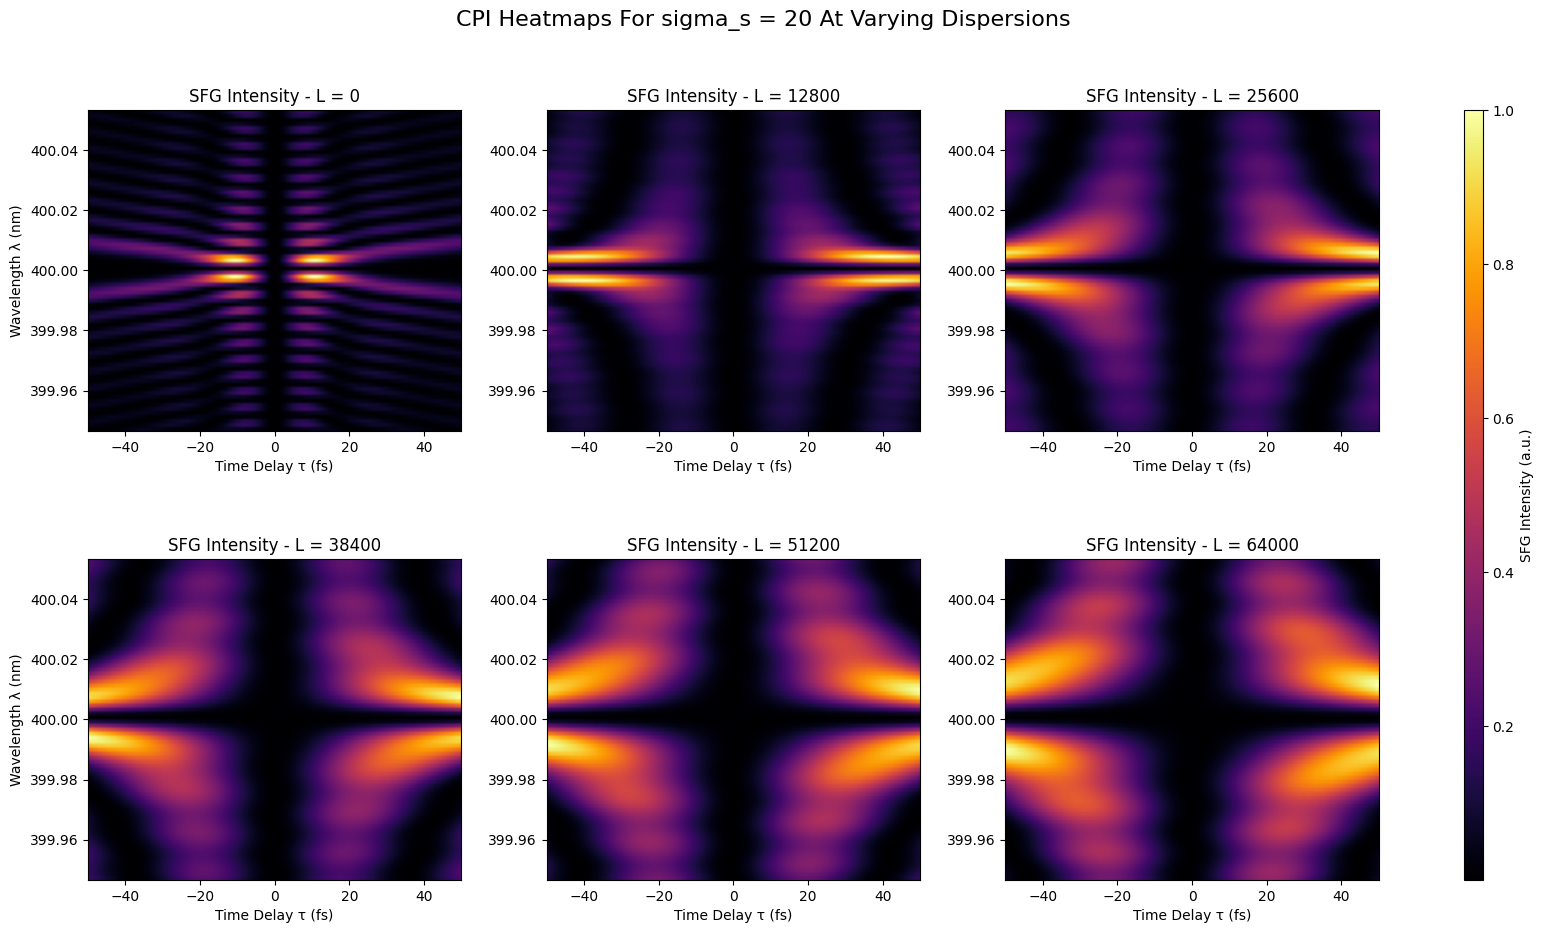

In [ ]:
super_duper_sigma = 20
super_duper_B = B*(10/(10+10))

super_duper_erf_pos = erf_2(super_duper_B,ws,w_0,super_duper_sigma)
super_duper_erf_neg = erf_2(-super_duper_B,ws,w_0,super_duper_sigma)

Ec_super_duper_erf = chirper(Ews, super_duper_erf_pos)
Ea_super_duper_erf = chirper(Ews, super_duper_erf_neg)

Ls = [0, 12800, 25600, 38400, 51200, 64000]
titles = ['L = 0', 'L = 12800', 'L = 25600', 'L = 38400', 'L = 51200', 'L = 64000']
super_taus = np.arange(-50, 50+0.5, 0.5)


CPIs = []

for L in Ls:
    cpi = CPI(Ec_super_duper_erf, Ea_super_duper_erf, ws, w_0, super_taus,  0.0223238*L)
    CPIs.append(cpi/np.max(cpi))


# --- Set up figure with GridSpec (2 rows x 3 columns + colorbar) ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05], height_ratios=[1, 1], wspace=0.3, hspace=0.4)

# Create 6 subplots in the 3x2 grid (rows 0 and 1, columns 0-2)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]

extent = [super_taus[0], super_taus[-1], wavelengths[end], wavelengths[start]]

# --- Plot heatmaps ---
for ax, data, title in zip(axes, CPIs, titles):
    im = ax.imshow(
        data[:, start:end].T,
        extent=extent,
        origin='lower',
        aspect='auto',
        cmap='inferno'
    )
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(f'SFG Intensity - {title}')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Label the first plot in each row
axes[0].set_ylabel('Wavelength λ (nm)')
axes[3].set_ylabel('Wavelength λ (nm)')

# --- Add colorbar in its own column (on the right) ---
cbar_ax = fig.add_subplot(gs[:, 3])  # spans both rows
fig.colorbar(im, cax=cbar_ax, label='SFG Intensity (a.u.)')

fig.suptitle("CPI Heatmaps For sigma_s = 20 At Varying Dispersions", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.96, 0.96])  # leave room for colorbar and title
plt.show()

    

Fit Parameters (t0, a1, a2, fwhm) for Linear CPI: [1.79462388e-07 1.00164186e+00 1.00265323e+00 1.58863326e+01]
Final Chi-Squared Value for Linear CPI: 0.00017140737306729566
Fit Parameters (t0, a1, a2, fwhm) for ERF CPI: [-4.10346809e-08  9.99846388e-01  1.00104929e+00  9.98980166e+00]
Final Chi-Squared Value for ERF CPI: 3.921577166647942e-05
Fit Parameters (t0, a1, a2, fwhm) for Super ERF CPI: [-3.18582659e-08  9.96563643e-01  1.00492476e+00  8.62814704e+00]
Final Chi-Squared Value for Super ERF CPI: 0.002591096080342273
Fit Parameters (t0, a1, a2, a3, fwhm) for Linear CPI (parabolic): [ 1.83882179e-07  9.97671791e-01 -8.39613862e-06  1.00137769e+00
  1.58337092e+01]
Final Chi-Squared Value for Linear CPI (parabolic): 0.0001507250311651456
Fit Parameters (t0, a1, a2, a3, fwhm) for ERF CPI (parabolic): [5.79860327e-11 1.00064508e+00 2.44362424e-06 1.00121509e+00
 9.99537320e+00]
Final Chi-Squared Value for ERF CPI (parabolic): 2.834304564196929e-05
Fit Parameters (t0, a1, a2, a3, fwh

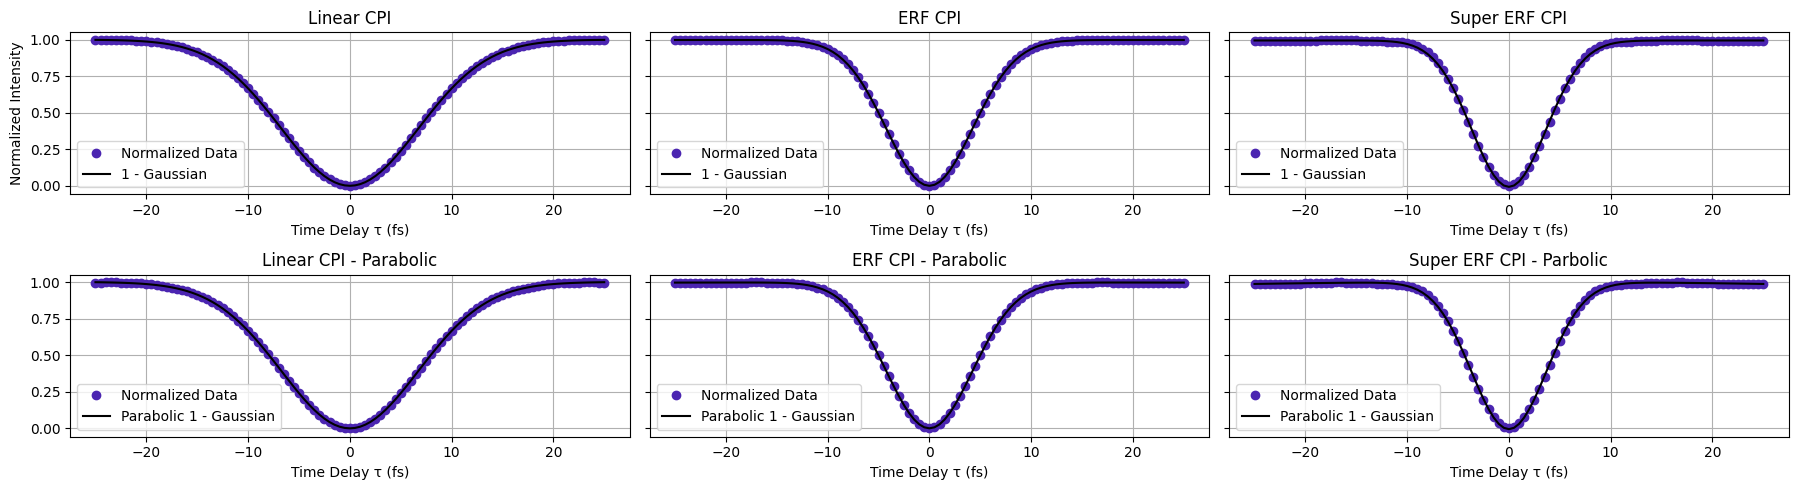

In [27]:
from scipy.optimize import minimize 

signals = []
curve_fits = []
params = []

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*math.log(2)*((t - t_0)**2)/fwhm**2)

def parabolic_one_minus_gaussian(t, t_0, a1, a2, a3, fwhm):
    return (a1 - a2*(t - t_0)**2)*(1 - a3*np.exp(-4*math.log(2)*((t - t_0)**2)/fwhm**2))

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

def chisq_parabolic(params, t, y):
    t0, a1, a2, a3, fwhm = params
    model = parabolic_one_minus_gaussian(t, t0, a1, a2, a3, fwhm)
    return np.sum((y - model)**2)

fit_names= []

for d, name in zip(datasets, titles):
    SFG_band = d[:, (wavelengths >= 399.5) & (wavelengths <= 400.5)]
    signal_vs_tau = np.sum(SFG_band, axis=1)  # integrate over wavelength axis

    signal_vs_tau_norm = (signal_vs_tau - np.min(signal_vs_tau))/(np.max(signal_vs_tau) - np.min(signal_vs_tau))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = minimize(chisq, init_guess, args=(taus, signal_vs_tau_norm), method='L-BFGS-B')

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = chisq(result.x, taus, signal_vs_tau_norm)

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve_fits.append(one_minus_gaussian(taus, *result.x))
    fit_names.append("1 - Gaussian")

#parabolic
for d, name in zip(datasets, titles):
    SFG_band = d[:, (wavelengths >= 399.5) & (wavelengths <= 400.5)]
    signal_vs_tau = np.sum(SFG_band, axis=1)  # integrate over wavelength axis
    signal_vs_tau_norm = (signal_vs_tau - np.min(signal_vs_tau))/(np.max(signal_vs_tau) - np.min(signal_vs_tau))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess_parabolic = [0, 0.0025, 0.00000001, 0.9, 10]

    # --- Fit the data ---
    result2 = minimize(chisq_parabolic, init_guess_parabolic, args=(taus, signal_vs_tau_norm), method='L-BFGS-B')

    # Extract the parameters
    params.append(result2.x)

    # Calculate the final chi-squared values
    final_chisq2 = chisq_parabolic(result2.x, taus, signal_vs_tau_norm)

    # Print the fit parameters and chi-squared values

    print(f"Fit Parameters (t0, a1, a2, a3, fwhm) for {name} (parabolic): {result2.x}")
    print(f"Final Chi-Squared Value for {name} (parabolic): {final_chisq2}")

    # Evaluate the fits
    curve_fits.append(parabolic_one_minus_gaussian(taus, *result2.x))

    fit_names.append("Parabolic 1 - Gaussian")

complete_titles = ["Linear CPI", "ERF CPI", "Super ERF CPI", "Linear CPI - Parabolic", "ERF CPI - Parabolic", "Super ERF CPI - Parbolic"]
# --- Create subplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit in zip(axes, signals, curve_fits, complete_titles, fit_names):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.tight_layout()
plt.show();

In [ ]:
Lvals = np.arange(0, 64001, 800)

#i wanna make this go into results folders
for L in Lvals:
    lin_cpi = CPI(Ec_lin, Ea_lin, ws, w_0, taus, 0.0223238*L)
    erf_cpi = CPI(Ec_erf, Ea_erf, ws, w_0, taus, 0.0223238*L)
    superf_cpi = CPI(Ec_superf, Ea_superf, ws, w_0, taus, 0.0223238*L)

    SFG_band_lin = lin_cpi[:, (wavelengths >= 399.5) & (wavelengths <= 400.5)]
    signal_vs_tau_lin = np.sum(SFG_band_lin, axis=1)
    np.savetxt(f"./linear_results/Linear_dip_{L}.txt", signal_vs_tau_lin, fmt="%.15f")

    SFG_band_erf = erf_cpi[:, (wavelengths >= 399.5) & (wavelengths <= 400.5)]
    signal_vs_tau_erf = np.sum(SFG_band_erf, axis=1)
    np.savetxt(f"./erf_results/ERF_dip_{L}.txt", signal_vs_tau_erf, fmt="%.15f")

    SFG_band_superf = superf_cpi[:, (wavelengths >= 399.5) & (wavelengths <= 400.5)]
    signal_vs_tau_superf = np.sum(SFG_band_superf, axis=1)
    np.savetxt(f"./super_erf_results/Super_ERF_dip_{L}.txt", signal_vs_tau_superf, fmt="%.15f")



FileNotFoundError: [Errno 2] No such file or directory: './linear_results/Linear_dip_0.txt'

L = 16000, FWHM = 10.01 fs


'plt.plot(Lvals, lin_fwhms, label = "linear")\nplt.plot(Lvals, erf_fwhms, label = "erf")\nplt.plot(Lvals, superf_fwhms, label = "super-erf")\nplt.ylim(0, 30)'

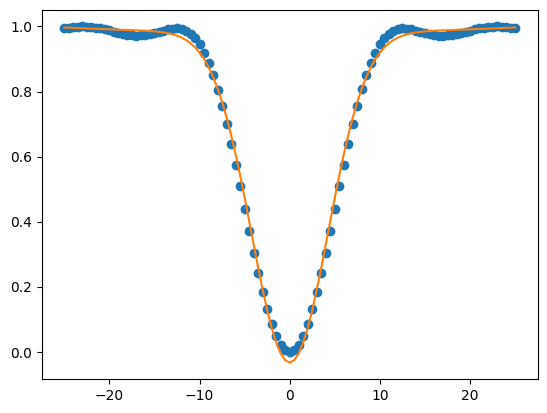

In [ ]:
from scipy.optimize import differential_evolution
Lvals = np.arange(0, 64001, 800)
lin_fwhms = []
erf_fwhms = []
superf_fwhms = []

# --- Initial guesses ---
init_guess_parabolic = [0, 0.0025, 0.00000001, 0.9, 10]

bounds = [(-10, 10), (0, 0.01), (0, 1e-4), (0, 1), (5, 40)]

def robust_fit(y_data):
    # Try L-BFGS-B first
    result = minimize(chisq_parabolic, init_guess_parabolic, args=(taus, y_data), method='L-BFGS-B')
    
    # Check for bad fits (e.g., negative width or high chi-squared)
    if result.fun > 0.01 or result.x[4] < 0:
        print("⚠️  Re-fitting with differential_evolution...")
        result = differential_evolution(lambda p: chisq_parabolic(p, taus, y_data), bounds)
    
    return result

for L in Lvals:
    lin_sig = np.loadtxt(f"./linear_results/Linear_dip_{L}.txt")
    erf_sig = np.loadtxt(f"./erf_results/ERF_dip_{L}.txt")
    superf_sig = np.loadtxt(f"./super_erf_results/Super_ERF_dip_{L}.txt")

    lin_norm = (lin_sig - np.min(lin_sig))/(np.max(lin_sig) - np.min(lin_sig))
    erf_norm = (erf_sig - np.min(erf_sig))/(np.max(erf_sig) - np.min(erf_sig))
    superf_norm = (superf_sig - np.min(superf_sig))/(np.max(superf_sig) - np.min(superf_sig))
    
    # --- Fit the data ---
    lin_result = minimize(chisq_parabolic, init_guess_parabolic, args=(taus, lin_norm), method='L-BFGS-B')
    #erf_result = robust_fit(erf_norm)
    #superf_result = robust_fit(superf_norm)
    erf_result = minimize(chisq_parabolic, init_guess_parabolic, args=(taus, erf_norm), method='L-BFGS-B')
    superf_result = minimize(chisq_parabolic, init_guess_parabolic, args=(taus, superf_norm), method='L-BFGS-B')

    
    lin_fwhms.append(lin_result.x[4])
    erf_fwhms.append(erf_result.x[4])
    superf_fwhms.append(superf_result.x[4])

    if L in [16000]:
        print(f"L = {L}, FWHM = {erf_result.x[4]:.2f} fs")
        plt.plot(taus, erf_norm,'o')
        plt.plot(taus, parabolic_one_minus_gaussian(taus, *erf_result.x))
    
Lvals_mm = Lvals/10000
#basinhopping 
'''plt.plot(Lvals, lin_fwhms, label = "linear")
plt.plot(Lvals, erf_fwhms, label = "erf")
plt.plot(Lvals, superf_fwhms, label = "super-erf")
plt.ylim(0, 30)'''
    

(0.0, 30.0)

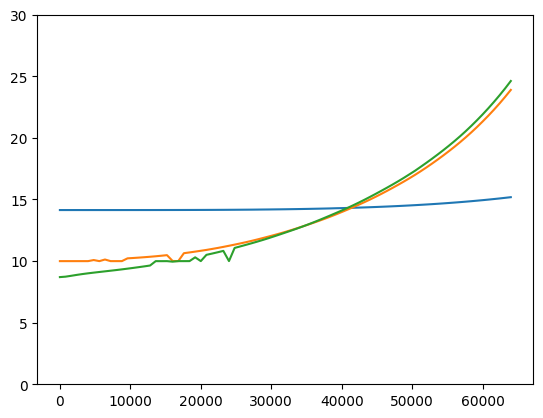

In [ ]:
plt.plot(Lvals, lin_fwhms, label = "linear")
plt.plot(Lvals, erf_fwhms, label = "erf")
plt.plot(Lvals, superf_fwhms, label = "super-erf")
plt.ylim(0, 30)

In [ ]:
import sympy as sy

def epsilon_derivative(order, w0_val):
    # Define symbolic variable
    w = sy.Symbol('w', real=True)

    # Constants (same units as in Mathematica: um/fs)
    c = 0.2998
    b1 = 1.03961212
    b2 = 0.231792344
    b3 = 1.01046945
    c1 = 6.00069867e-3
    c2 = 2.00179144e-2
    c3 = 1.03560653e2

    # Sellmeier n(w)
    omega = 2 * sy.pi * c / w
    n_squared = 1 + (b1 * omega**2)/(omega**2 - c1) + \
                    (b2 * omega**2)/(omega**2 - c2) + \
                    (b3 * omega**2)/(omega**2 - c3)
    n_w = sy.sqrt(n_squared)

    # Phase constant
    k_w = n_w * w / c

    # Derivative of desired order
    dkw = sy.diff(k_w, w, order)

    # Substitute w0 value
    epsilon = (L_val / 2) * dkw.subs(w, w0_val).evalf()

    return epsilon


In [ ]:
ws[0] = 1e-6

def BK7_epsilon(w, w0):
    c = 0.2998; #(*um/fs*)
    b1 = 1.03961212; #(*for BK7 glass*)
    b2 = 0.231792344
    b3 = 1.01046945
    c1 = 6.00069867e-3 #(*um^2*)
    c2 = 2.00179144e-2
    c3 = 1.03560653e2

    k_w = w*(np.sqrt(1 + (b1*(2*np.pi*c/w)**2)/((2*np.pi*c/w)**2 - c1) + 
                     (b2*(2*np.pi*c/w)**2)/((2*np.pi*c/w)**2 - c2) + 
                     (b3*(2*np.pi*c/w)**2)/((2*np.pi*c/w)**2 - c3)))/c
    
    k_deriv = np.sqrt(1 +((4*b1*(c**2)*(np.pi**2))/(-c1*((w - w0)**2) + (2*c*np.pi)**2)) + 
                      ((4*b2*(c**2)*(np.pi**2))/(-c2*((w - w0)**2) + (2*c*np.pi)**2)) + 
                      ((4*b3*(c**2)*(np.pi**2))/(-c3*((w - w0)**2) + (2*c*np.pi)**2)))/c + (w - w0)*(
                          (32*b1*(c*np.pi)**4)/(((w - w0)**5)*((-c1 + ((2*c*np.pi)**2)/((w - w0)**2))**2)) +
                          (32*b2*(c*np.pi)**4)/(((w - w0)**5)*((-c2 + ((2*c*np.pi)**2)/((w - w0)**2))**2)) +
                          (32*b3*(c*np.pi)**4)/(((w - w0)**5)*((-c3 + ((2*c*np.pi)**2)/((w - w0)**2))**2)) -
                          (8*b1*(c*np.pi)**2)/(((w - w0)**3)*(-c1 + ((2*c*np.pi)**2)/((w - w0)**2))) -
                          (8*b2*(c*np.pi)**2)/(((w - w0)**3)*(-c2 + ((2*c*np.pi)**2)/((w - w0)**2))) -
                          (8*b3*(c*np.pi)**2)/(((w - w0)**3)*(-c3 + ((2*c*np.pi)**2)/((w - w0)**2))))/(
                              2*c*np.sqrt(1 + (b1*(2*np.pi*c/(w - w0))**2)/((2*np.pi*c/(w - w0))**2 - c1) + 
                                          (b2*(2*np.pi*c/(w - w0))**2)/((2*np.pi*c/(w - w0))**2 - c2) + 
                                          (b3*(2*np.pi*c/(w - w0))**2)/((2*np.pi*c/(w - w0))**2 - c3)))

    return k_w - k_deriv


phase_test = BK7_epsilon( ws, w_0)

print(phase_test)


[-0.28507039  4.99415888]


# THIS DOESNT WORK
Idea: use numpys broadcasting to make all array sizes the same, so then we can use vectorization to get rid of the very slow loop 
Reality: semi bricks your computer, likely bc you dont have enough RAM according to chatgpt -> takes about 10-20s longer and makes your computer shit itself in the process -> likely need > 16gb, probably 32 

for some reasons maggies plot is one pixel wider on the y-axis than mine. is this because i removed the first points where w = 0?

taus = np.arange(-25, 25 + 0.5, 0.5)  # shape (N_tau,)
N_tau = taus.shape[0]

# Shape (1, N_freq) for broadcasting
ws_b = ws[np.newaxis, :]  # shape (1, N_freq)
taus_b = taus[:, np.newaxis]  # shape (N_tau, 1)

# Reference electric field (Ec + Ea) repeated over taus
Eref_w = (Ec_lin + Ea_lin)[np.newaxis, :] * np.exp(1j * ws_b * taus_b)  # shape (N_tau, N_freq)

# Sample electric field: fixed in time
Esamp_w = Esampler(Ec_lin, Ea_lin, ws, w_0, 0)
Esamp_t = np.conj(ifft(np.conj(Esamp_w), norm='ortho'))  # shape (N_freq,)

# IFFT Eref to time domain
Eref_t = np.conj(ifft(np.conj(Eref_w), axis=1, norm='ortho'))  # shape (N_tau, N_freq)

# Multiply in time domain (broadcast Esamp_t to all taus)
Esfg_t = Eref_t * Esamp_t[np.newaxis, :]  # shape (N_tau, N_freq)

# FFT back to frequency domain
Esfg_w = np.conj(fft(np.conj(Esfg_t), axis=1, norm='ortho'))  # shape (N_tau, N_freq)

# Compute intensity
SFG_data = np.abs(Esfg_w)**2  # shape (N_tau, N_freq)

wavelengths = 2*np.pi*c*1e9/(ws*1e15)

start = 299753
end = 299833

SFG_data_norm = SFG_data / np.max(SFG_data)

# Plot
plt.figure(figsize=(8, 6))
extent = [taus[0], taus[-1], wavelengths[end], wavelengths[start]]

plt.imshow(
    SFG_data_norm[:, start:end].T,
    extent=extent,
    origin='lower',
    aspect='auto',
    cmap='inferno'
)

plt.colorbar(label='SFG Intensity (a.u.)')
plt.xlabel('Time Delay τ (fs)')
plt.ylabel('Wavelength λ (nm)')
plt.title('SFG Intensity vs Time Delay and Wavelength')
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()



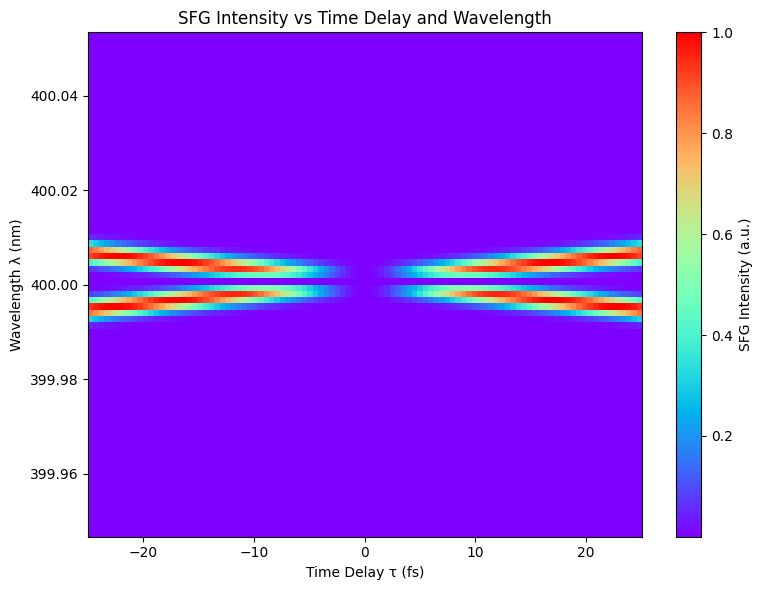

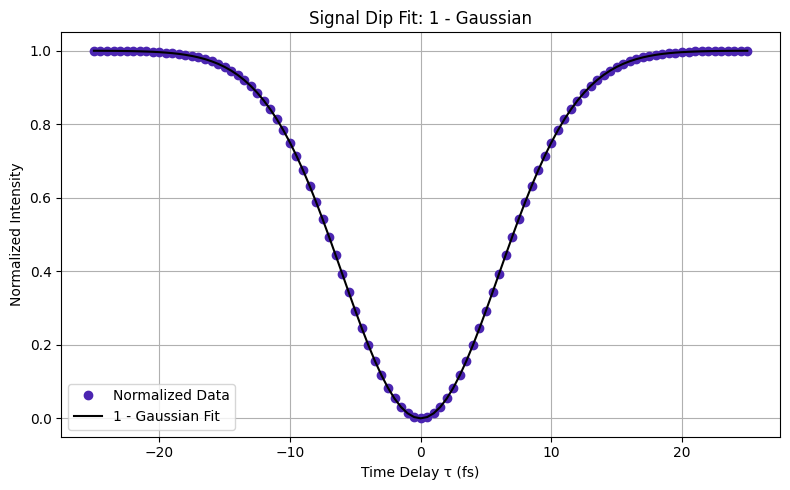

Fitted parameters: a = -0.0000, t0 = 1.00 fs, FWHM = 14.14 fs
